![Portada](../recursos/img/portada_eda_matrix.png)

***

## 📖 Descripción del EDA

En 1999, el mundo se encontró con una pregunta incómoda: **¿y si todo lo que percibes como real no lo es?**

En _The Matrix_, el protagonista descubre que **la humanidad vive atrapada en una simulación digital** creada por máquinas, mientras sus cuerpos son utilizados como fuente de energía. 

La película consiguió combinar filosofía, acción y efectos visuales nunca vistos hasta entonces y con sus sagas dividió al público entre quienes la vivieron como puro entretenimiento y quienes vieron en ella algo mucho más profundo.

Este EDA (Análisis Exploratorio de Datos) nace precisamente de esa batalla de audiencia. Y es a través de los datos que busco explorar el impacto real de la saga. Por eso, me pregunto si realmente revolucionó el cine de ciencia ficción, si su temática trascendió la pantalla hasta llegar a la comunidad científica y si las secuelas fueron realmente peores o simplemente más difíciles de comprender.

***

## 💊 Hipótesis

#### 1.- **_The Matrix_ revolucionó el género de la ciencia ficción** 

La película estableció un nuevo estándar de inversión en películas de ciencia ficción. A partir de entonces, las películas del género optaron por impulsar los efectos digitales, con lo que los presupuestos y los especialistas en VFX aumentaron en número por el uso de nuevas tecnologías para dejar con la boca abierta a los espectadores.

#### 2.- **La realidad como simulación: de la ficción a la cultura popular**

La saga *The Matrix* consolidó la [_Teoría de la Simulación_](https://es.wikipedia.org/wiki/Hip%C3%B3tesis_de_simulaci%C3%B3n) como un debate presente tanto en la cultura popular como en el mundo académico. A través del análisis de la producción de papers científicos, de algunos de sus conceptos en la literatura y, más adelante, en plataformas como YouTube, exploraré si la saga sigue siendo relevante.

#### 3.- **El declive de la saga: ¿motivada por el descenso de calidad?**

Se propone que con una mayor narrativa y más términos complejos, menor es la conexión emocional y la valoración del público general. En realidad, quizás las películas no eran peores, sino que no llegaron a ser comprendidas. Buscaré los motivos de la desconexión del público con las secuelas.

***

## 🔌 Datos

Dado que la temática de las hipótesis es variada, también lo serán las distintas fuentes de datos que tengo que utilizar para poder contrastarlas. **A continuación muestro cada hipótesis y las fuentes** que serán utilizadas:

#### Fuentes Hipótesis 1 (__The Matrix_ revolucionó el género de la ciencia ficción_)
Utilizo datasets de métricas de cine, obtenidos de Kaggle. En concreto, uso datasets de [Tmbd](https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata), con el que puedo estudiar los **presupuestos** de las películas por año y la **cantidad de especialistas en efectos especiales** que han trabajado en ciencia ficción en las últimas décadas.

#### Fuentes Hipótesis 2 (_La realidad como simulación: de la ficción a la cultura popular_)
Para contrastar la hipótesis uso la **librería arXiv**. También utilizo **Google Ngrams**, que es una herramienta de Google que analiza la frecuencia con la que aparecen palabras o frases en millones de libros digitalizados a lo largo del tiempo. Y para adentrarme en **YouTube**, utilizaré su API para investigar vídeos que toquen temas relacionados con la saga. 

#### Fuentes Hipótesis 3 (_El declive de la saga: ¿motivada por el descenso de calidad?_)
Para acabar he elegido unos datasets muy curiosos, ya que cada uno de ellos contiene las transcripciones de las películas, que me servirán para estudiar si los guiones eran peores o, simplemente, se fueron complicando. Los datasets están agrupados en Kaggle bajo el nombre [The Matrix](https://www.kaggle.com/datasets/nixongeno/the-matrix-movie-transcripts). Para el procesamiento de las transcripciones se utilizarán dos librerías especializadas en procesamiento de lenguaje natural: **NLTK y SpaCy**. Y dado que el tercero no me valía, he tenido que hacer **webscrapping** para crear el csv correspondiente.

***

##  💰 🎞️ HIPÓTESIS 1: _The Matrix_ revolucionó el género de la ciencia ficción

#### Contrasto la primera hipótesis, que planteaba que a partir de la aparición de _The Matrix_ en las salas de cine, el género de la ciencia ficción vio aumentado sus presupuestos de manera general y también la cantidad de personas que participaban en los procesos de efectos especiales.

### Parte 1: Evolución de los presupuestos en la ciencia ficción

#### Empiezo cargando librerías y archivos.

In [12]:
# importo librerías necesarias

import pandas as pd
import ast
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.ticker as mticker
import numpy as np


ruta_hipotesis1 = "src/datos/brutos/hipotesis_1/tmdb_5000_movies.csv" # ruta al dataset

df_5000movies = pd.read_csv(ruta_hipotesis1) # cargo el csv
print(f"Dataset cargado con {df_5000movies.shape[0]} películas y {df_5000movies.shape[1]} columnas") # imprimo mensaje

Dataset cargado con 4803 películas y 20 columnas


#### Miro la información del dataset.

In [13]:
df_5000movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status                4803 non-n

#### Ahora buscaré qué columnas que contienen valores NuN y veré qué puedo hacer con ellas.

In [14]:
nulos = df_5000movies.isnull().sum() # sumo los valores NuN de cada columna
nulos[nulos>0] # muestro los que son mayores a 0

homepage        3091
overview           3
release_date       1
runtime            2
tagline          844
dtype: int64

#### La **columna homepage** es la página web de cada película y es irrelevante para el estudio, así que será **eliminada**. De la misma manera, **tagline** hace referencia a una frase que representa a la película, a menudo utilizada en los pósters, y también puede ser **eliminada**. La columna **overview** ofrece el resumen de la película, se puede **eliminar**, **runtime** es el tiempo que dura, esta **la puedo conservar** por si me sirve para algún tipo de análisis posterior. Por último, **release_date sí es totalmente relevante**, ya que es la fecha de lanzamiento de la película en cines.

In [15]:
df_5000movies.head(1) # miro la pinta de un registro para entenderlo mejor

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800


#### Y antes de empezar a limpiar valores NuN, también quiero mirar el resto de columnas, para conocer qué datos me valen y de cuáles puedo prescindir:

* **budget**: me vale
* **genres**: me vale
* **homepage**: fuera
* **id**: me vale
* **keywords**: fuera
* **original_language**: fuera
* **original_title**: fuera
* **overview**: fuera
* **popularity**: fuera
* **production_companies**: me vale
* **production_countries**: fuera
* **release_date**: me vale
* **revenue**: me vale
* **runtime**: fuera
* **spoken_languages**: fuera
* **status**: fuera
* **tagline**: fuera
* **title**: me vale
* **vote_average**: fuera
* **vote_count**: fuera

#### Limpio el dataframe df_5000movies y me quedo solamente con las columnas que me valen.

In [17]:
# creo una lista con las columnas a eliminar

columnas_fuera = ["homepage", "keywords", "original_language", "original_title", "overview", "popularity", "production_countries", "production_companies", "runtime", "spoken_languages", "status", "tagline", "vote_average", "vote_count"]

df_5000movies_limpio = df_5000movies.drop(columns=columnas_fuera) # elimino las columnas

df_5000movies_limpio.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   budget        4803 non-null   int64
 1   genres        4803 non-null   str  
 2   id            4803 non-null   int64
 3   release_date  4802 non-null   str  
 4   revenue       4803 non-null   int64
 5   title         4803 non-null   str  
dtypes: int64(3), str(3)
memory usage: 225.3 KB


#### Ahora tengo que ver cuál es la película que tiene un NaN en release_date, por si puedo encontrarlo en internet o, simplemente, elimino el registro y punto.

In [18]:
peliculaNaN = df_5000movies_limpio["release_date"].isna() # obtengo la máscara para encontrar el registro NaN

df_5000movies_limpio[peliculaNaN] # busco el registro

,budget,genres,id,release_date,revenue,title
4553,0,[],380097,NaN,0,America Is Still the Place


#### Viendo que la película no tiene presupuesto, géneros o ingresos, lo más sencillo es no complicarse y eliminarla del dataframe limpio.

In [19]:
df_5000movies_limpio = df_5000movies_limpio.dropna(subset=["release_date"]) # elimino la fila de la columna release_Date con NaN
df_5000movies_limpio.info()

<class 'pandas.DataFrame'>
Index: 4802 entries, 0 to 4802
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   budget        4802 non-null   int64
 1   genres        4802 non-null   str  
 2   id            4802 non-null   int64
 3   release_date  4802 non-null   str  
 4   revenue       4802 non-null   int64
 5   title         4802 non-null   str  
dtypes: int64(3), str(3)
memory usage: 262.6 KB


#### Ahora vemos que tenemos 4802 registros, uno menos que antes, pero ya tenemos las columnas que queremos y sin nulos. Ahora, eso sí, tengo otro problema: la columna de género dice que contiene un string, pero es un texto que hay que convertir a un diccionario para obtener los valores que necesito.

In [20]:
df_5000movies_limpio["genres"].head(5)

0    [{"id": 28, "name": "Action"}, {"id": 12, "nam...
1    [{"id": 12, "name": "Adventure"}, {"id": 14, "...
2    [{"id": 28, "name": "Action"}, {"id": 12, "nam...
3    [{"id": 28, "name": "Action"}, {"id": 80, "nam...
4    [{"id": 28, "name": "Action"}, {"id": 12, "nam...
Name: genres, dtype: str

#### Crearé una función sencilla para poder convertir los valores de la columna genre en una lista con los géneros de cada película del dataframe.

In [21]:
def extraer_generos(texto): # inicio la función
    lista = ast.literal_eval(texto) # convierto el string en diccionario
    return [genero["name"] for genero in lista] # recorro el diccionario y me quedo solo con el campo name

df_5000movies_limpio["genres"] = df_5000movies_limpio["genres"].apply(extraer_generos) # extraigo los géneros

print(f"Esta es la lista de géneros ya modificada y lista para la hipótesis:")

df_5000movies_limpio["genres"] # muestro los géneros

Esta es la lista de géneros ya modificada y lista para la hipótesis:


0       [Action, Adventure, Fantasy, Science Fiction]
1                        [Adventure, Fantasy, Action]
2                          [Action, Adventure, Crime]
3                    [Action, Crime, Drama, Thriller]
4                [Action, Adventure, Science Fiction]
                            ...                      
4798                        [Action, Crime, Thriller]
4799                                [Comedy, Romance]
4800               [Comedy, Drama, Romance, TV Movie]
4801                                               []
4802                                    [Documentary]
Name: genres, Length: 4802, dtype: object

#### Ahora que ya tengo la columna genres perfecta, tengo que quedarme con un dataframe solamente de película de ciencia ficción. Para ello, crearé una función muy sencilla, que me permita ver si en esta columna existe el término "Science Fiction". Y así obtendré el dataframe df_5000movies_scifi.

In [22]:
def sci_fi(generos): # buscare los valores de cada registro de la columna genres
    return "Science Fiction" in generos # miro si Science Fiction aparece en la lista de cada registro

df_5000movies_scifi = df_5000movies_limpio[df_5000movies_limpio["genres"].apply(sci_fi)] # aplico la función a la columna genres de df_5000movies_limpio

df_5000movies_scifi.info()

<class 'pandas.DataFrame'>
Index: 535 entries, 0 to 4796
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   budget        535 non-null    int64 
 1   genres        535 non-null    object
 2   id            535 non-null    int64 
 3   release_date  535 non-null    str   
 4   revenue       535 non-null    int64 
 5   title         535 non-null    str   
dtypes: int64(3), object(1), str(2)
memory usage: 29.3+ KB


In [23]:
df_5000movies_scifi.head(10)

,budget,genres,id,release_date,revenue,title
0,237000000,"[Action, Adventure, Fantasy, Science Fiction]",19995,2009-12-10,2787965087,Avatar
4,260000000,"[Action, Adventure, Science Fiction]",49529,2012-03-07,284139100,John Carter
7,280000000,"[Action, Adventure, Science Fiction]",99861,2015-04-22,1405403694,Avengers: Age of Ultron
10,270000000,"[Adventure, Fantasy, Action, Science Fiction]",1452,2006-06-28,391081192,Superman Returns
14,225000000,"[Action, Adventure, Fantasy, Science Fiction]",49521,2013-06-12,662845518,Man of Steel
16,220000000,"[Science Fiction, Action, Adventure]",24428,2012-04-25,1519557910,The Avengers
18,225000000,"[Action, Comedy, Science Fiction]",41154,2012-05-23,624026776,Men in Black 3
26,250000000,"[Adventure, Action, Science Fiction]",271110,2016-04-27,1153304495,Captain America: Civil War
27,209000000,"[Thriller, Action, Adventure, Science Fiction]",44833,2012-04-11,303025485,Battleship
28,150000000,"[Action, Adventure, Science Fiction, Thriller]",135397,2015-06-09,1513528810,Jurassic World


#### Ya tengo un dataframe solamente de películas de ciencia ficción. Tengo un total de 535 registros. Ahora es turno de convertir los datos de la columna release_date y quedarme únicamente con el año, que es lo que realmente me interesa para comparar presupuestos antes y después de _The Matrix_.

In [24]:
df_5000movies_scifi['release_date'] = pd.to_datetime(df_5000movies_scifi['release_date']) # convierto el string de la columna en un objeto de fecha
df_5000movies_scifi['year'] = df_5000movies_scifi['release_date'].dt.year # simplemente extraigo el año

df_5000movies_scifi['year'] # muestro la columna modificada

0       2009
4       2012
7       2015
10      2006
14      2013
        ... 
4745    1962
4758    2014
4764    2014
4787    2011
4796    2004
Name: year, Length: 535, dtype: int32

#### Aún queda algún problema por solucionar. Si antes vi que un registro tenía un presupuesto igual a cero, ¿puede ser que existan más registro así? Tengo que comprobarlo.

In [25]:
(df_5000movies_scifi['budget'] == 0).sum() # busco los registros con budget = 0

np.int64(60)

In [26]:
df_5000movies_scifi = df_5000movies_scifi[df_5000movies_scifi['budget'] > 0] # creo una máscara para dejar el dataframe solo con los registros que tienen presupuesto
df_5000movies_scifi.info()

<class 'pandas.DataFrame'>
Index: 475 entries, 0 to 4796
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   budget        475 non-null    int64         
 1   genres        475 non-null    object        
 2   id            475 non-null    int64         
 3   release_date  475 non-null    datetime64[us]
 4   revenue       475 non-null    int64         
 5   title         475 non-null    str           
 6   year          475 non-null    int32         
dtypes: datetime64[us](1), int32(1), int64(3), object(1), str(1)
memory usage: 27.8+ KB


#### Me guardo este dataframe como un archivo .csv para tener las carpetas del repositorio ordenadas con los datos.

In [28]:
df_5000movies_scifi.to_csv('src/datos/procesados/hipotesis_1/peliculas_scifi_presupuestos.csv', index=False)

#### Empezaré ya con el análisis. Para ello, lo primero que quiero hacer es centrarme en los presupuestos. Agruparé películas por año y calcularé el presupuesto medio.

In [30]:
presupuesto_anual = df_5000movies_scifi.groupby('year')['budget'].mean().reset_index() # creo un dataframe agrupando películas por año y obteniendo su presupuesto medio
presupuesto_anual.columns = ['year', 'presupuesto_medio'] # renombro las columnas
presupuesto_anual['presupuesto_medio'] = presupuesto_anual['presupuesto_medio'].round(0).astype(int) # elimino decimales y convierto a int
presupuesto_anual.head()

,year,presupuesto_medio
0,1927,92620000
1,1953,210000
2,1954,5000000
3,1962,62000
4,1966,1377800


#### Tengo datos desde el año 1927, pero creo que para el contexto de este EDA, existen décadas prácticamente irrelevantes. Por tanto, dado que Star Wars salió en 1977 y que podría marcar el inicio de la ciencia ficción más moderna, podemos establecer ese como punto de corte.

In [31]:
presupuesto_anual = presupuesto_anual[presupuesto_anual['year'] >= 1977] # ahora el dataframe solo incluye registros a partir de 1977

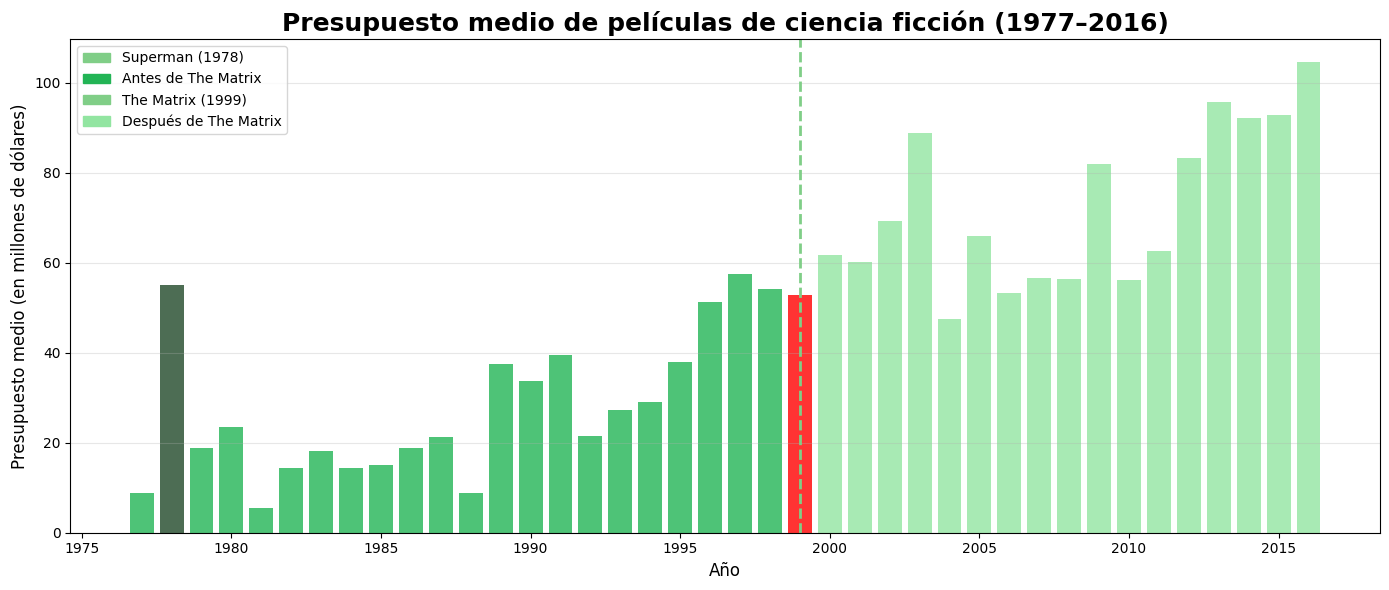

In [32]:
fig, ax = plt.subplots(figsize=(14, 6))

# Asigno colores según el año

colores = []
for year in presupuesto_anual['year']:
    if year == 1978:
        colores.append('#204829')
    elif year == 1999:
        colores.append('red')
    elif year < 1999:
        colores.append('#22b455')
    else:
        colores.append('#92e5a1')

ax.bar(presupuesto_anual['year'], presupuesto_anual['presupuesto_medio'] / 1_000_000, color=colores, alpha=0.8)

ax.axvline(1999, color='#80ce87', linestyle='--', linewidth=2)

# Leyenda manual
leyenda = [
    Patch(color='#80ce87',       label='Superman (1978)'),
    Patch(color='#22b455',  label='Antes de The Matrix'),
    Patch(color='#80ce87',        label='The Matrix (1999)'),
    Patch(color='#92e5a1', label='Después de The Matrix'),
]
ax.legend(handles=leyenda, fontsize=10)

ax.set_title('Presupuesto medio de películas de ciencia ficción (1977–2016)', fontsize=18, fontweight='bold')
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Presupuesto medio (en millones de dólares)', fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusión:

El gráfico muestra el presupuesto medio de las películas de ciencia ficción año a año desde 1977 hasta 2016. La línea roja marca el estreno de The Matrix en 1999. Destaca la barra dorada de 1978, correspondiente a Superman, que con 55 millones de dólares fue una superproducción excepcional para su época y un caso aislado que no marcó tendencia en el género. A partir de ahí, antes de 1999 los presupuestos rondaban entre 20 y 60 millones de dólares con bastante variación entre años. Tras el estreno de The Matrix la tendencia cambia claramente: los presupuestos suben de forma más consistente y se sitúan por encima de los 60 millones, llegando a superar los 100 millones en los últimos años del dataset. Y hay que tener en cuenta que no tenemos datos de los últimos años.

En pocas palabras: después de The Matrix, gastar más dinero en ciencia ficción se convirtió en la norma. 

_Nota: los presupuestos están en dólares corrientes de cada año, sin ajuste por inflación. Esto significa que parte del crecimiento que se observa se debe simplemente a que el dinero valía menos con el paso del tiempo. Con un ajuste por inflación, los presupuestos antiguos serían más altos de lo que aparecen, por lo que la diferencia real entre antes y después de 1999 sería menor, aunque la tendencia al alza probablemente seguiría siendo visible._

***

### Parte 2: Evolución de los especialistas en cine de ciencia ficción

#### Cargo el csv de créditos y miro los tres primeros registros y el info() para saber qué datos tengo entre manos.

In [33]:
creditos = pd.read_csv('src/datos/brutos/hipotesis_1/tmdb_5000_credits.csv')
creditos.head(3)

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


In [34]:
creditos.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   movie_id  4803 non-null   int64
 1   title     4803 non-null   str  
 2   cast      4803 non-null   str  
 3   crew      4803 non-null   str  
dtypes: int64(1), str(3)
memory usage: 150.2 KB


#### Ya estoy observando que tanto el cast (actores y actrices) como el crew (todo el personal involucrado en las películas) no son simples strings, sino que estoy ante formato json.

In [35]:
print(creditos['crew'][0])

[{"credit_id": "52fe48009251416c750aca23", "department": "Editing", "gender": 0, "id": 1721, "job": "Editor", "name": "Stephen E. Rivkin"}, {"credit_id": "539c47ecc3a36810e3001f87", "department": "Art", "gender": 2, "id": 496, "job": "Production Design", "name": "Rick Carter"}, {"credit_id": "54491c89c3a3680fb4001cf7", "department": "Sound", "gender": 0, "id": 900, "job": "Sound Designer", "name": "Christopher Boyes"}, {"credit_id": "54491cb70e0a267480001bd0", "department": "Sound", "gender": 0, "id": 900, "job": "Supervising Sound Editor", "name": "Christopher Boyes"}, {"credit_id": "539c4a4cc3a36810c9002101", "department": "Production", "gender": 1, "id": 1262, "job": "Casting", "name": "Mali Finn"}, {"credit_id": "5544ee3b925141499f0008fc", "department": "Sound", "gender": 2, "id": 1729, "job": "Original Music Composer", "name": "James Horner"}, {"credit_id": "52fe48009251416c750ac9c3", "department": "Directing", "gender": 2, "id": 2710, "job": "Director", "name": "James Cameron"}, 

#### Por tanto, del dataset solamente necesito las columnas movie_id y crew. Sin embargo, de la columna crew solamente necesito las personas que participaban en Visual Effects. Así que crearé una función para extraer a la gente que ha trabajado en ese campo. Después, cambiaré el nombre de la columna e incluiré en su interior una lista con las personas que me interesan para la segunda parte de la hipótesis.

In [36]:
def extraer_efectos(texto): # inicio la función
    lista = ast.literal_eval(texto) # convierto el string en diccionario
    return [persona['name'] for persona in lista if persona['department'] == 'Visual Effects'] # recorro el diccionario y me quedo solo con el campo name, pero si la persona está en el 
                                                                                               # departamento de efectos visuales

creditos['efectos'] = creditos['crew'].apply(extraer_efectos) # cambio el nombre de la columna crew a efectos y aplico la función para
                                                              # quedarme con lo que me interesa

creditos[['movie_id', 'efectos']].head(5) # muestro los cinco primeros registros del dataframe filtrado

,movie_id,efectos
0,19995,"[Jill Brooks, Richard Martin, Steven Quale, Jo..."
1,285,[]
2,206647,"[Laura Schultz, Sean McGrath, Mark Curtis, Ken..."
3,49026,"[May Leung, Mike Chambers, Pete Bebb, Claudia ..."
4,49529,"[Peter Chiang, Chris Corbould, Sue Rowe, Danie..."


#### Ya tengo el dataframe listo, pero, en realidad, lo único que necesito es la cantidad de personas que han participado en las películas en el apartados de efectos visuales. Para ello sustituyo la lista de personas por un conteo de los elementos de la lista. Es decir, cambio nombres por el total de personas que participaron.

In [37]:
creditos['total_personas_efectos'] = creditos['efectos'].apply(len) # añado una columna, que contendrá el número de personas de efectos
creditos[['movie_id', 'total_personas_efectos']].head(5) # muestro los primeros valores

,movie_id,total_personas_efectos
0,19995,26
1,285,0
2,206647,24
3,49026,7
4,49529,5


#### Para poder jugar con datos y gráficos, toca unir el dataset de películas de ciencia ficción con este que acabo de crear.

In [38]:
df_efectos = df_5000movies_scifi.merge(creditos[['movie_id', 'total_personas_efectos']], left_on='id', right_on='movie_id')
df_efectos.info()

<class 'pandas.DataFrame'>
RangeIndex: 475 entries, 0 to 474
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   budget                  475 non-null    int64         
 1   genres                  475 non-null    object        
 2   id                      475 non-null    int64         
 3   release_date            475 non-null    datetime64[us]
 4   revenue                 475 non-null    int64         
 5   title                   475 non-null    str           
 6   year                    475 non-null    int32         
 7   movie_id                475 non-null    int64         
 8   total_personas_efectos  475 non-null    int64         
dtypes: datetime64[us](1), int32(1), int64(5), object(1), str(1)
memory usage: 31.7+ KB


#### Me guardo el nuevo dataframe con el nombre peliculas_scifi_efectos.

In [39]:
df_efectos.to_csv('src/datos/procesados/hipotesis_1/peliculas_scifi_efectos.csv', index=False)

#### Ahora agruparé por año el dataframe de efectos y calcularé la media de personas en cada año que trabajaban en este campo en las películas de ciencia ficción.

In [40]:
efectos_anual = df_efectos.groupby('year')['total_personas_efectos'].mean().reset_index() # agrupo por año y calculo la media de personas
efectos_anual.columns = ['year', 'media_trabajadores_efectos'] # el nuevo dataframe tendrá dos columnas: year y media_trabajadores_efectos
efectos_anual['media_trabajadores_efectos'] = efectos_anual['media_trabajadores_efectos'].round(0).astype(int) # convierto a int y redondeo sin decimales
efectos_anual = efectos_anual[efectos_anual['year'] >= 1977] # filtro desde el año 1977 (para comparar de la misma manera que en presupuestos)
efectos_anual.head(10) # previsualizo cómo ha quedado el dataframe

,year,media_trabajadores_efectos
13,1977,0
14,1978,0
15,1979,0
16,1980,1
17,1981,1
18,1982,0
19,1983,0
20,1984,0
21,1985,0
22,1986,2


#### Genero el gráfico en el que comparo la media de trabajadores de efectos visuales desde 1977 hasta 2016.

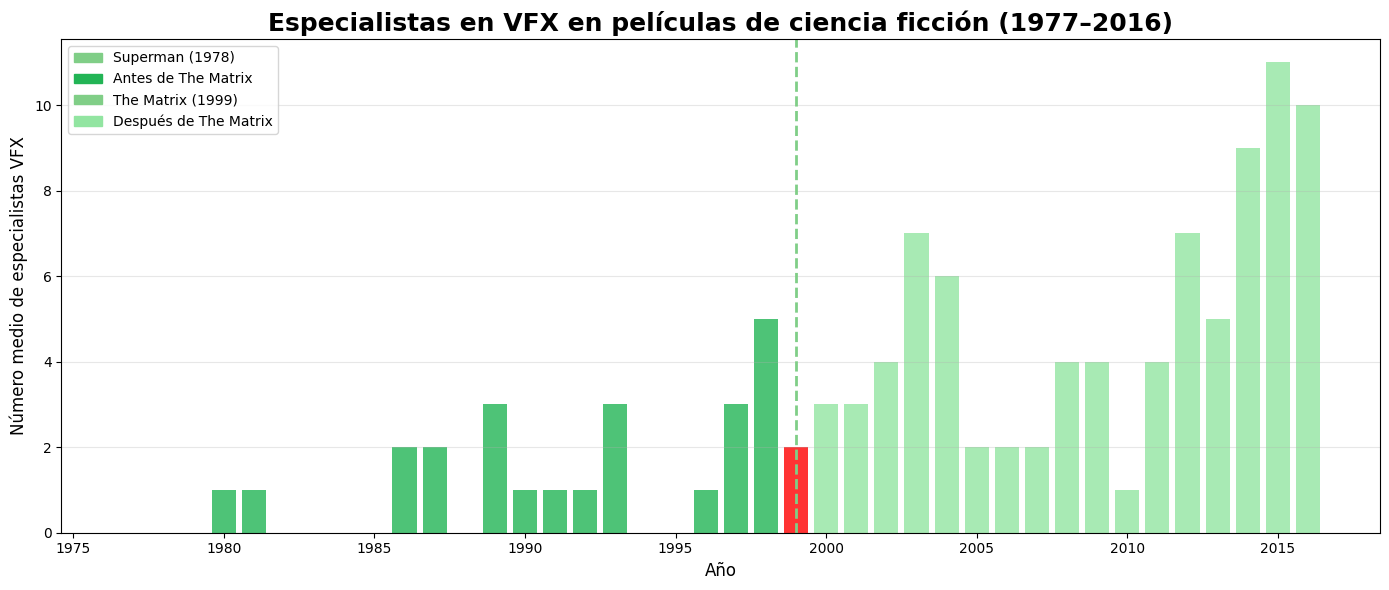

In [41]:
fig, ax = plt.subplots(figsize=(14, 6))

colores = []
for year in efectos_anual['year']:
    if year == 1978:
        colores.append('#204829')
    elif year == 1999:
        colores.append('red')
    elif year < 1999:
        colores.append('#22b455')
    else:
        colores.append('#92e5a1')

ax.bar(efectos_anual['year'], efectos_anual['media_trabajadores_efectos'], color=colores, alpha=0.8)

ax.axvline(1999, color='#80ce87', linestyle='--', linewidth=2)


leyenda = [
    Patch(color='#80ce87',       label='Superman (1978)'),
    Patch(color='#22b455',  label='Antes de The Matrix'),
    Patch(color='#80ce87',        label='The Matrix (1999)'),
    Patch(color='#92e5a1', label='Después de The Matrix'),
]
ax.legend(handles=leyenda, fontsize=10)

ax.set_title('Especialistas en VFX en películas de ciencia ficción (1977–2016)', fontsize=18, fontweight='bold')
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Número medio de especialistas VFX', fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusión:

El gráfico muestra el número medio de especialistas en efectos visuales por película de ciencia ficción entre 1977 y 2016. La tendencia es más evidente que en el análisis de presupuestos: antes de 1999 las barras raramente superan los 3 o 4 profesionales de media, mientras que tras el estreno de The Matrix el número escala de forma progresiva y sostenida hasta superar los 10 en 2015 y 2016.

A diferencia del análisis de presupuestos, aquí no hay distorsión por inflación: estamos contando personas, no dinero, lo que hace la conclusión más directa. 

Dicho esto, el crecimiento no responde solo a un efecto Matrix. La mejora continua de las herramientas digitales (renderizado, motion capture, compositing) fue bajando el umbral técnico para producir efectos complejos, lo que permitió a más producciones incorporarlos y generó una demanda creciente de profesionales especializados. Matrix fue la película que convenció a la industria de apostar fuerte por los efectos visuales, pero fue la mejora de la tecnología lo que permitió que esa apuesta se mantuviera y creciera con los años. Y si tenemos en cuenta que muchas tareas que antes necesitaban equipos grandes hoy las resuelve el software, el crecimiento real en el uso de VFX fue probablemente aún mayor de lo que refleja este dato.

***

## 🌐 🧠 HIPÓTESIS 2: La realidad como simulación: de la ficción a la cultura popular

#### Para la segunda hipótesis, me he planteado utilizar la **librería arxiv** para buscar la influencia de la saga en papers científicos. Esta parte ha quedado descartada, como verás en las próximas líneas de código, porque el volumen de resultados era demasiado pequeño y disperso como para extraer ninguna conclusión relevante. Por eso viré hacia la cultura popular y me planteé si _The Matrix_ había influido tanto en literatura, analizo mediante **Google Ngrams**, como en la plataforma audiovisual por excelencia, **YouTube**.

### Parte 1: La falta de resultados en el análisis de papers

#### Importo la librería arxiv y veo qué contiene y con qué puedo trabajar.

In [42]:
# importo las librerías necesarias

import arxiv
import pandas as pd
import time

cliente = arxiv.Client(page_size=10, delay_seconds=3, num_retries=3) # abro la conexión con arxiv para obtener los datos de su API

# incluyo los temas a buscar
queries = [
    "simulation hypothesis physics",
    "simulated universe cosmology",
    "digital physics reality",
    "Nick Bostrom simulation argument",
    "simulation argument philosophy"
]

todos_resultados = []

# itero entre los temas por relevancia

for query in queries:
    busqueda = arxiv.Search(
        query=query,
        max_results=50,
        sort_by=arxiv.SortCriterion.Relevance
    )
    
    for paper in cliente.results(busqueda):
        todos_resultados.append({
            "titulo": paper.title,
            "anio": paper.published.year,
            "categoria": paper.primary_category,
            "query": query
        })

df_papers = pd.DataFrame(todos_resultados).drop_duplicates(subset='titulo')
print(f"Total papers únicos: {len(df_papers)}")
df_papers.head(10)

Total papers únicos: 211


,titulo,anio,categoria,query
0,Physics Briefing Book,2019,hep-ex,simulation hypothesis physics
1,Physics and Technology of the Next Linear Coll...,1996,hep-ex,simulation hypothesis physics
2,MHD analysis on the physical designs of CFETR ...,2021,physics.plasm-ph,simulation hypothesis physics
3,Specification of the Q Hypothesis: An Alternat...,2006,quant-ph,simulation hypothesis physics
4,Impact of Detector Simulation in Particle Phys...,2017,hep-ex,simulation hypothesis physics
5,Simulating Customer Experience and Word Of Mou...,2010,cs.MA,simulation hypothesis physics
6,Physics at a future Neutrino Factory and super...,2007,hep-ph,simulation hypothesis physics
7,Astrophysical constraints on the simulation hy...,2025,physics.pop-ph,simulation hypothesis physics
8,Why Machine Learning Integrated Patient Flow S...,2021,cs.LG,simulation hypothesis physics
9,Modelling and simulating retail management pra...,2010,cs.AI,simulation hypothesis physics


#### De los temas planteados ("simulation hypothesis physics", "simulated universe cosmology", "digital physics reality", "Nick Bostrom simulation argument" y "simulation argument philosophy) he obtenido un total de 211 papers. Y aún tengo que filtrar por las categorías que me interesan (física popular y divulgación, relatividad general y cosmología cuántica, física cuántica, astrofísica, cosmología e historia y filosofía de la física). 

In [43]:
categorias_relevantes = [
    'physics.pop-ph',  # física popular y divulgación
    'gr-qc',           # relatividad general y cosmología cuántica
    'quant-ph',        # física cuántica
    'astro-ph',        # astrofísica
    'astro-ph.CO',     # cosmología
    'physics.hist-ph', # historia y filosofía de la física
]

df_papers_filtrado = df_papers[df_papers['categoria'].isin(categorias_relevantes)]
print(f"Papers tras filtrar por categoría: {len(df_papers_filtrado)}")
df_papers_filtrado

Papers tras filtrar por categoría: 81


,titulo,anio,categoria,query
3,Specification of the Q Hypothesis: An Alternat...,2006,quant-ph,simulation hypothesis physics
7,Astrophysical constraints on the simulation hy...,2025,physics.pop-ph,simulation hypothesis physics
20,Machine learning meets quantum physics,2019,physics.pop-ph,simulation hypothesis physics
37,Monte Carlo Simulation of Quantum Computation,1997,quant-ph,simulation hypothesis physics
38,`What is a Thing?': Topos Theory in the Founda...,2008,quant-ph,simulation hypothesis physics
...,...,...,...,...
234,Measurement Theory in the Philosophy of Science,2012,physics.hist-ph,simulation argument philosophy
240,Reconstructing William Lane Craig's Explanatio...,2020,physics.hist-ph,simulation argument philosophy
242,Conceptual Preconditions of Overcoming of Rela...,2014,physics.hist-ph,simulation argument philosophy
243,Annotated bibliography: Philosophy of Astrophy...,2023,physics.hist-ph,simulation argument philosophy


#### Dado que me he quedado con tan solo 81 resultados válidos, no me parece que el camino de los papers sea el más interesante para el EDA. Así que lo descarto y continúo con la cultura popular.

### Parte 2: Google Ngrams y _The Matrix_

#### Google Ngrams rastrea la frecuencia de palabras en millones de libros publicados entre 1800 y 2019. Es la única fuente que cubre el antes y el después de 1999. Lo analizamos tanto en inglés como en español para ver si el impacto fue global.

In [47]:
import os
OUTPUT_DIR = 'src/datos/procesados/hipotesis_2'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Carpeta: {OUTPUT_DIR}')

Carpeta: src/datos/procesados/hipotesis_2


#### Uso la API de Google Ngrams para descargar la frecuencia de aparición de cuatro términos filosóficos en libros publicados entre 1980 y 2019, tanto en inglés como en español. La función ngrams hace la petición y devuelve un DataFrame con un valor por año para cada término. Los resultados se guardan en formato csv para usarlos en los gráficos.

In [49]:
import requests

def ngrams(terms, start=1980, end=2019, corpus='en-2019', smoothing=3):
    url = 'https://books.google.com/ngrams/json'
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120.0.0.0 Safari/537.36',
        'Referer': 'https://books.google.com/ngrams'
    }
    params = {
        'content': ','.join(terms),
        'year_start': start,
        'year_end': end,
        'corpus': corpus,
        'smoothing': smoothing
    }
    r = requests.get(url, params=params, headers=headers, timeout=20)
    data = r.json()
    df = pd.DataFrame({'year': list(range(start, end + 1))})
    for serie in data:
        df[serie['ngram']] = serie['timeseries']
    return df

terminos_en = ['simulation theory', 'virtual reality consciousness', 'what is reality', 'philosophy of mind']
terminos_es = ['teoría de la simulación', 'realidad virtual', 'qué es la realidad', 'filosofía de la mente']

print('Descargando libros en inglés...')
df_en = ngrams(terminos_en, corpus='en-2019')
print(f'OK — {len(df_en)} años')

print('Descargando libros en español...')
df_es = ngrams(terminos_es, corpus='es-2019')
print(f'OK — {len(df_es)} años')

df_en.to_csv(os.path.join(OUTPUT_DIR, 'ngrams_en.csv'), index=False)
df_es.to_csv(os.path.join(OUTPUT_DIR, 'ngrams_es.csv'), index=False)
print('CSVs guardados')

Descargando libros en inglés...
OK — 40 años
Descargando libros en español...
OK — 40 años
CSVs guardados


#### Genero 8 gráficos en una figura, organizados en dos filas — la superior para los términos en inglés y la inferior para los equivalentes en español. Cada gráfico muestra la evolución temporal de un término entre 1980 y 2019, con una línea vertical en 1999 que marca el estreno de _The Matrix_. El área bajo la curva está rellena para facilitar la lectura visual de la tendencia. El gráfico se guarda como PNG en la carpeta de procesados de la hipótesis.

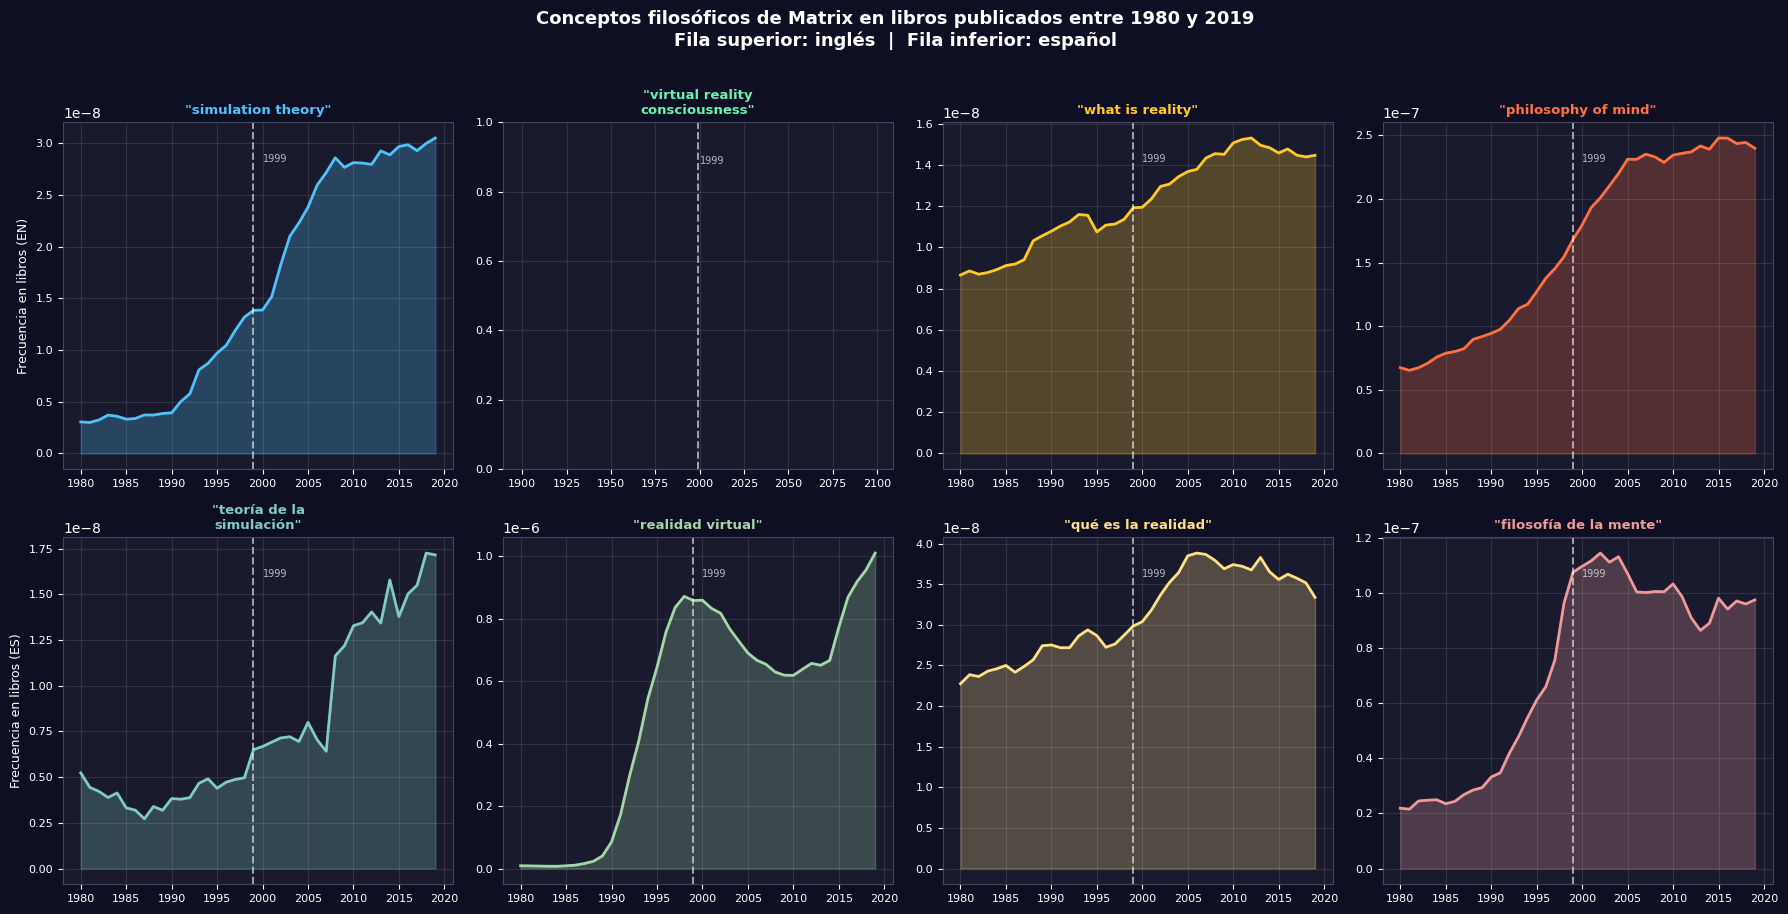

In [51]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.patch.set_facecolor('#0f0f23')

colores_en = ['#4fc3f7', '#69f0ae', '#ffca28', '#ff7043']
labels_en  = ['"simulation theory"', '"virtual reality\nconsciousness"', '"what is reality"', '"philosophy of mind"']
colores_es = ['#80cbc4', '#a5d6a7', '#ffe082', '#ef9a9a']
labels_es  = ['"teoría de la\nsimulación"', '"realidad virtual"', '"qué es la realidad"', '"filosofía de la mente"']

for i, (col, label, color) in enumerate(zip(terminos_en, labels_en, colores_en)):
    ax = axes[0][i]
    ax.set_facecolor('#1a1a2e')
    if col in df_en.columns:
        ax.fill_between(df_en['year'], df_en[col], alpha=0.25, color=color)
        ax.plot(df_en['year'], df_en[col], color=color, linewidth=2)
    ax.axvline(1999, color='white', linestyle='--', linewidth=1.4, alpha=0.6)
    ax.text(2000, ax.get_ylim()[1] * 0.88, '1999', color='white', fontsize=7, alpha=0.7)
    ax.set_title(label, fontsize=9.5, fontweight='bold', color=color)
    ax.tick_params(colors='white', labelsize=8)
    ax.spines[:].set_color('#444466')
    ax.grid(True, alpha=0.10, color='white')
    if i == 0:
        ax.set_ylabel('Frecuencia en libros (EN)', color='white', fontsize=9)

for i, (col, label, color) in enumerate(zip(terminos_es, labels_es, colores_es)):
    ax = axes[1][i]
    ax.set_facecolor('#1a1a2e')
    if col in df_es.columns:
        ax.fill_between(df_es['year'], df_es[col], alpha=0.25, color=color)
        ax.plot(df_es['year'], df_es[col], color=color, linewidth=2)
    ax.axvline(1999, color='white', linestyle='--', linewidth=1.4, alpha=0.6)
    ax.text(2000, ax.get_ylim()[1] * 0.88, '1999', color='white', fontsize=7, alpha=0.7)
    ax.set_title(label, fontsize=9.5, fontweight='bold', color=color)
    ax.tick_params(colors='white', labelsize=8)
    ax.spines[:].set_color('#444466')
    ax.grid(True, alpha=0.10, color='white')
    if i == 0:
        ax.set_ylabel('Frecuencia en libros (ES)', color='white', fontsize=9)

fig.suptitle('Conceptos filosóficos de Matrix en libros publicados entre 1980 y 2019\nFila superior: inglés  |  Fila inferior: español',
             fontsize=13, fontweight='bold', color='white', y=1.01)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ngrams_bilingue.png'), dpi=150, bbox_inches='tight', facecolor='#0f0f23')

### Conclusión:

Los gráficos muestran un patrón claro: términos como "simulation theory" o "filosofía de la mente" despegan en los libros justo a partir de 1999, tanto en inglés como en español. Matrix no solo entretuvo — introdujo preguntas en el discurso escrito que antes prácticamente no existían.

### Parte 3: Adentrándonos en la madriguera del conejo de YouTube

Utilizo YouTube Data API v3 para buscar vídeos por términos y obtener distintas métricas, como puede ser el caso de visualizaciones, likes, comentarios y fecha de publicación. Busco en inglés y en español para capturar el fenómeno global. Importo la API key, que la tengo en un archivo .env en la raíz del proyecto para que no se suba a GitHub.

In [53]:
from dotenv import load_dotenv
import os

load_dotenv('../.env')
YOUTUBE_API_KEY = os.getenv('YOUTUBE_API_KEY')
print('Key cargada:', YOUTUBE_API_KEY is not None)

Key cargada: True


#### Creo una función para hacer dos llamadas por búsqueda: la primera obtiene los IDs de los vídeos más vistos y la segunda obtiene sus estadísticas. Busco 5 términos ('teoría de la simulación matrix explicada', 'vivimos en una simulación filosofía', 'filosofía de matrix explicada', 'qué es la realidad filosofía', 'realidad virtual conciencia filosofía') en cada idioma, elimino duplicados y descarto vídeos sin visualizaciones. El resultado se guarda en CSV.

In [64]:
# La función de búsqueda en YouTube hace dos llamadas a la API:
# 1) busca vídeos por término y obtiene sus IDs
# 2) recupera las estadísticas de cada vídeo (vistas, likes y comentarios)

def buscar_videos_youtube(query, api_key, lang, max_results=50):

    # Paso 1: buscar IDs 
    r = requests.get(
        'https://www.googleapis.com/youtube/v3/search',
        params={
            'part': 'snippet', 'q': query, 'type': 'video',
            'maxResults': max_results, 'order': 'viewCount',  # ordeno por vistas
            'relevanceLanguage': lang, 'key': api_key         # filtro por idioma
        }, timeout=15
    )
    items = r.json().get('items', [])
    ids = [item['id']['videoId'] for item in items if 'videoId' in item['id']]
    if not ids:
        return pd.DataFrame()  # si no hay resultados devuelvo un df vacío

    # Paso 2: obtengo estadísticas de cada vídeo por su ID
    r2 = requests.get(
        'https://www.googleapis.com/youtube/v3/videos',
        params={'part': 'statistics,snippet', 'id': ','.join(ids), 'key': api_key},
        timeout=15
    )
    resultados = []
    for v in r2.json().get('items', []):
        stats   = v.get('statistics', {})
        snippet = v.get('snippet', {})
        fecha_str = snippet.get('publishedAt', '')
        fecha = pd.to_datetime(fecha_str[:10]) if fecha_str else pd.NaT
        resultados.append({
            'titulo':      snippet.get('title', ''),
            'canal':       snippet.get('channelTitle', ''),
            'fecha':       fecha,
            'año':         fecha.year if pd.notna(fecha) else None,
            'vistas':      int(stats.get('viewCount', 0)),
            'likes':       int(stats.get('likeCount', 0)),
            'comentarios': int(stats.get('commentCount', 0)),
            'idioma':      lang,
            'query':       query
        })
    return pd.DataFrame(resultados)

# Términos de búsqueda

queries_en = [
    'simulation theory explained matrix',
    'are we living in a simulation philosophy',
    'matrix philosophy explained',
    'what is reality philosophy',
    'virtual reality consciousness philosophy'
]
queries_es = [
    'teoría de la simulación matrix explicada',
    'vivimos en una simulación filosofía',
    'filosofía de matrix explicada',
    'qué es la realidad filosofía',
    'realidad virtual conciencia filosofía'
]

# Ejecutamos las búsquedas (se espera 1 segundo entre llamadas para respetar el rate limit)

dfs = []
print('Buscando en inglés...')
for q in queries_en:
    print(f'  → {q}')
    dfs.append(buscar_videos_youtube(q, YOUTUBE_API_KEY, lang='en'))
    time.sleep(1)

print('Buscando en español...')
for q in queries_es:
    print(f'  → {q}')
    dfs.append(buscar_videos_youtube(q, YOUTUBE_API_KEY, lang='es'))
    time.sleep(1)

# Combino los resultados, elimino duplicados y descarto vídeos sin vistas

df_youtube = pd.concat(dfs).drop_duplicates(subset='titulo').reset_index(drop=True)
df_youtube = df_youtube[df_youtube['vistas'] > 0]

# Recalculo el año desde la fecha para evitar Nones

df_youtube['fecha'] = pd.to_datetime(df_youtube['fecha'], errors='coerce')
df_youtube['año'] = df_youtube['fecha'].dt.year

print(f'\nVídeos únicos: {len(df_youtube)}')
print(f'  Inglés:  {len(df_youtube[df_youtube["idioma"]=="en"])}')
print(f'  Español: {len(df_youtube[df_youtube["idioma"]=="es"])}')

df_youtube.to_csv(os.path.join(OUTPUT_DIR, 'youtube_matrix_filosofia.csv'), index=False)
print()

Buscando en inglés...
  → simulation theory explained matrix
  → are we living in a simulation philosophy
  → matrix philosophy explained
  → what is reality philosophy
  → virtual reality consciousness philosophy
Buscando en español...
  → teoría de la simulación matrix explicada
  → vivimos en una simulación filosofía
  → filosofía de matrix explicada
  → qué es la realidad filosofía
  → realidad virtual conciencia filosofía

Vídeos únicos: 451
  Inglés:  225
  Español: 226



#### Obtengo los diez vídeos con más visitas.

In [65]:
df_youtube.sort_values('vistas', ascending=False)[['titulo', 'canal', 'año', 'vistas', 'idioma']].head(10)

,titulo,canal,año,vistas,idioma
225,Fallos En La Realidad Que Demuestran Que Vivim...,Dani itss,2023,29954674,es
130,String Theory Explained – What is The True Nat...,Kurzgesagt – In a Nutshell,2018,26239013,en
3,Craziest Coincidence or Glitch in the Matrix ?...,Kuldeep Singhania Shorts,2025,25932282,en
50,Is Anything Real?,Vsauce,2013,23376119,en
4,Are we Stuck in the Matrix 🤯🌌 ? | Kuldeep Sing...,Kuldeep Singhania Shorts,2025,22010902,en
0,Is Reality Real? The Simulation Argument,Kurzgesagt – In a Nutshell,2017,21602084,en
1,We Live in a Simulation. The evidence is every...,The Why Files,2022,18263981,en
2,The woman in the red dress | The Matrix [Open ...,Flashback FM,2019,17452842,en
133,“Perception vs Reality | Deep Philosophy Shorts”,𝑾𝒆𝒍𝒍 𝑴𝒊𝒏𝒅 𝑯𝒖𝒃®,2025,15387603,en
131,Ep : 1 | What is Philosophy? Dr. Vikas Divyakirti,Vikas Divyakirti,2022,14378893,en


#### Agrupo las vistas por año e idioma y las convierto a millones. Además, pivoto para tener una columna por idioma y filtro desde el año 2010. Este filtro se debe a que antes de 2010 el contenido de YouTube era bastante más pobre y el gráfico podría distorsionarse.

In [67]:
por_año_idioma = df_youtube.groupby(["año", "idioma"])["vistas"].sum().reset_index() # agrupo por año e idioma y sumo vistas

por_año_idioma["vistas_M"] = por_año_idioma["vistas"] / 1_000_000 # creo la columna vistas_M (millones)

pivot = por_año_idioma.pivot(index="año", columns="idioma", values="vistas_M").fillna(0) # pivoto para la columna idioma

pivot = pivot[pivot.index >= 2010] # filtro de 2010 en adelante

#### Muestro las visualizaciones totales por año, separando inglés y español en barras apiladas. El objetivo es ver si el interés en YouTube creció con el tiempo y si hay picos coincidentes con eventos clave como las declaraciones de Musk en 2016, el estreno de _Matrix Resurrections_ en 2021 o el lanzamiento de ChatGPT en 2022.

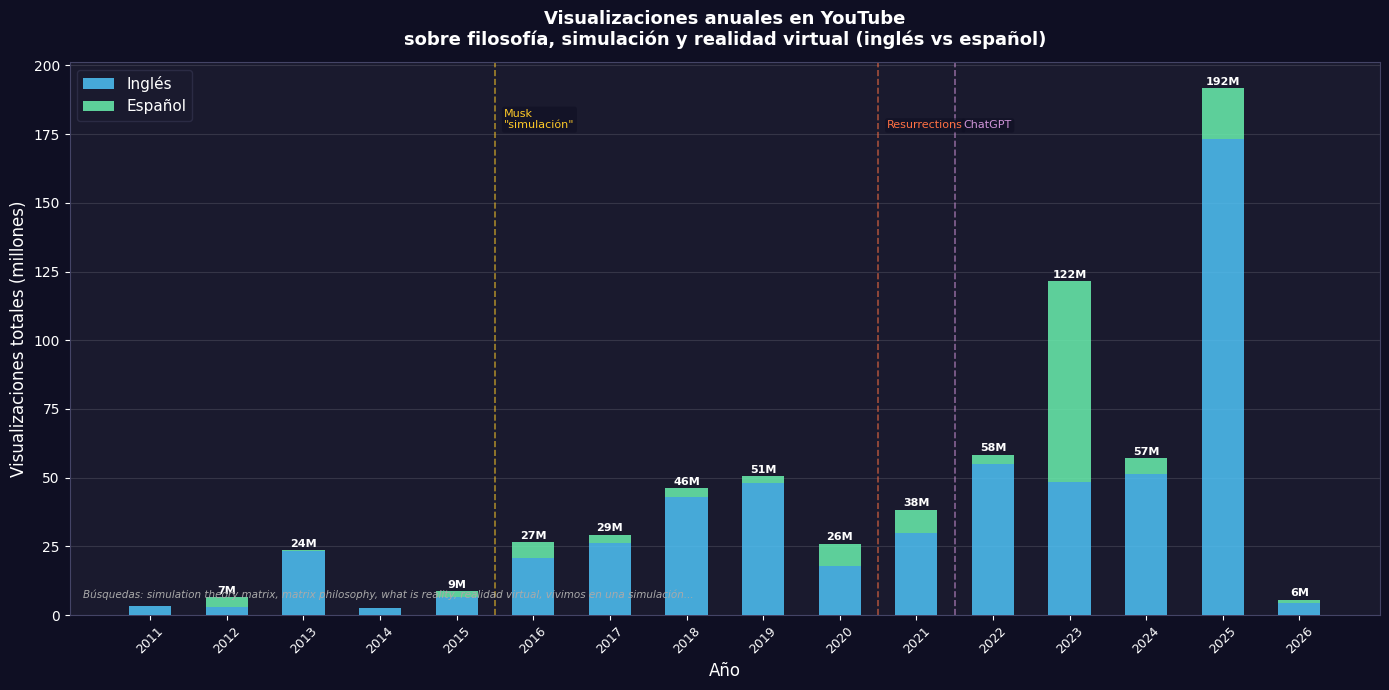

In [68]:
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor("#0f0f23")
ax.set_facecolor("#1a1a2e")

años = pivot.index
x = np.arange(len(años))
ancho = 0.55

bars_en = ax.bar(x, pivot.get("en", 0), ancho,
                 color="#4fc3f7", alpha=0.85, label="Inglés", zorder=3)
bars_es = ax.bar(x, pivot.get("es", 0), ancho,
                 bottom=pivot.get("en", 0),
                 color="#69f0ae", alpha=0.85, label="Español", zorder=3)

for i, año in enumerate(años):
    en_val = pivot["en"].get(año, 0) if "en" in pivot.columns else 0
    es_val = pivot["es"].get(año, 0) if "es" in pivot.columns else 0
    total = en_val + es_val
    if total > 5:
        ax.text(i, total + 0.5, f"{total:.0f}M",
                ha="center", va="bottom", fontsize=8, color="white", fontweight="bold")

años_lista = list(años)
for año_evento, label, color in [
    (2016, 'Musk\n"simulación"', "#ffca28"),
    (2021, "Resurrections", "#ff7043"),
    (2022, "ChatGPT", "#ce93d8"),
]:
    if año_evento in años_lista:
        idx = años_lista.index(año_evento)
        ax.axvline(idx - 0.5, color=color, linestyle="--", linewidth=1.2, alpha=0.6)
        ylim = ax.get_ylim()
        ax.text(idx - 0.38, (ylim[1] - ylim[0]) * 0.88 + ylim[0], label,
                color=color, fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="#0f0f23", alpha=0.6, edgecolor="none"))

ax.set_xticks(x)
ax.set_xticklabels(años, rotation=45, color="white", fontsize=9)
ax.set_xlabel("Año", fontsize=12, color="white")
ax.set_ylabel("Visualizaciones totales (millones)", fontsize=12, color="white")
ax.tick_params(colors="white")
ax.spines[:].set_color("#444466")
ax.grid(True, axis="y", alpha=0.12, color="white")
ax.set_title("Visualizaciones anuales en YouTube\nsobre filosofía, simulación y realidad virtual (inglés vs español)",
             fontsize=13, fontweight="bold", color="white", pad=12)
ax.legend(fontsize=11, framealpha=0.3, facecolor="#1a1a2e",
          labelcolor="white", edgecolor="#555577", loc="upper left")
ax.text(0.01, 0.03,
        "Búsquedas: simulation theory matrix, matrix philosophy, what is reality, realidad virtual, vivimos en una simulación...",
        transform=ax.transAxes, fontsize=7.5, color="#aaaaaa", style="italic")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "youtube_barras.png"), dpi=150, bbox_inches="tight", facecolor="#0f0f23")


### Conclusión:

El gráfico confirma que el interés en YouTube por estos temas no ha parado de crecer. El volumen era residual hasta 2016, cuando las declaraciones de Musk sobre la simulación dieron el primer gran impulso. A partir de 2021, con _Matrix Resurrections_ y la irrupción de ChatGPT, el crecimiento se acelera hasta alcanzar los 192M de visualizaciones en 2025, siendo este el pico histórico. El contenido en español gana peso a partir de 2022, lo que confirma que el fenómeno es global. Una película de 1999 sigue generando más conversación en YouTube hoy que en cualquier momento anterior de su historia.

***

## 💔 🎭 HIPÓTESIS 3: El declive de la saga: ¿motivada por el descenso de calidad?

Utilizo datasets con transcripciones de las películas para estudiar si los guiones eran peores o, simplemente, se fueron complicando. Sin embargo, no solo analizo el guion como tal, sino que los comparo con las puntuaciones en iMDB. Además, obtengo curiosidades de las transcripciones para responder si hubo descenso de calidad y fueron otros factores los que hicieron que la saga no perdurase en el tiempo.

#### Empiezo analizando 

In [71]:
# Importo las librerías necesarias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import nltk # librería para analizar texto
import os
from collections import Counter # me sirve para contar palabras frecuentes
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

# Descargo los recursos de nltk

nltk.download('vader_lexicon', quiet=True)  # modelo de sentimiento 
nltk.download('stopwords', quiet=True)      # descarga la lista de stopwords de NLTK, que son palabras vacías en inglés como "the", "a", "is", "in", "of"

# Rutas de entrada y salida — apuntan a la carpeta de procesados de la hipótesis 3

DATA_DIR = os.path.join('src', 'datos', 'procesados', 'hipotesis_3')
OUTPUT_DIR = DATA_DIR

# Cargo los tres guiones ya limpios y listos para analizar
m1 = pd.read_csv(os.path.join(DATA_DIR, 'matrix1_clean.csv'))
m2 = pd.read_csv(os.path.join(DATA_DIR, 'matrix2_clean.csv'))
m3 = pd.read_csv(os.path.join(DATA_DIR, 'matrix3_clean.csv'))

print(f'Matrix 1: {len(m1)} líneas de diálogo')
print(f'Matrix 2: {len(m2)} líneas de diálogo')
print(f'Matrix 3: {len(m3)} líneas de diálogo')

Matrix 1: 622 líneas de diálogo
Matrix 2: 768 líneas de diálogo
Matrix 3: 755 líneas de diálogo


#### He podido cargar los csv limpios, ya que hice previamente un proceso de limpieza de los guiones. Ese proceso está desgranado en `src/notebooks/hipotesis3.ipynb`.

#### Calculo las métricas principales de cada guion: sentimiento de cada línea de diálogo con VADER, longitud media de las frases, riqueza léxica (porcentaje de palabras únicas sobre el total) y número de personajes distintos. Estas métricas son la base de los tres gráficos que siguen a continuación.

In [73]:
# Ejecuto el analizador de sentimiento VADER y las stopwords en inglés

sia = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))

# Para cada guion calculo el sentimiento de cada línea (valor entre -1 y 1) y el número de palabras por frase

for df in [m1, m2, m3]:
    df['sentimiento'] = df['Character_dialogue'].apply(
        lambda x: sia.polarity_scores(str(x))['compound']
    )
    df['num_palabras'] = df['Character_dialogue'].str.split().str.len()

# Función que devuelve el vocabulario limpio de un guion (eliminando stopwords y símbolos)

def vocab_limpio(df):
    palabras = df['Character_dialogue'].str.cat(sep=' ').lower().split()
    return [w for w in palabras if w not in stop_words and w.isalpha()]

vocab1 = vocab_limpio(m1)
vocab2 = vocab_limpio(m2)
vocab3 = vocab_limpio(m3)

# Riqueza léxica: cuanto mayor, más variado es el vocabulario

riqueza1 = len(set(vocab1)) / len(vocab1) * 100
riqueza2 = len(set(vocab2)) / len(vocab2) * 100
riqueza3 = len(set(vocab3)) / len(vocab3) * 100

# Número de personajes distintos en cada guion

pers1 = m1['Character_Name'].nunique()
pers2 = m2['Character_Name'].nunique()
pers3 = m3['Character_Name'].nunique()

# Imprimo resultados

print('Métricas calculadas:')
print(f'  Personajes: {pers1} / {pers2} / {pers3}')
print(f'  Riqueza léxica: {riqueza1:.1f}% / {riqueza2:.1f}% / {riqueza3:.1f}%')
print(f'  Sentimiento medio: {m1["sentimiento"].mean():.3f} / {m2["sentimiento"].mean():.3f} / {m3["sentimiento"].mean():.3f}')
print(f'  Media palabras/frase: {m1["num_palabras"].mean():.1f} / {m2["num_palabras"].mean():.1f} / {m3["num_palabras"].mean():.1f}')

Métricas calculadas:
  Personajes: 30 / 78 / 67
  Riqueza léxica: 41.2% / 43.4% / 39.2%
  Sentimiento medio: -0.004 / 0.034 / 0.017
  Media palabras/frase: 11.8 / 10.4 / 9.7


##### Gráfico 1 — ¿Quién habla más en cada película?: Si las secuelas fallaron por dispersión narrativa, debería verse en el reparto de diálogos: _The Matrix_, con un protagonista claro, las secuelas con el protagonismo fragmentado entre decenas de personajes.

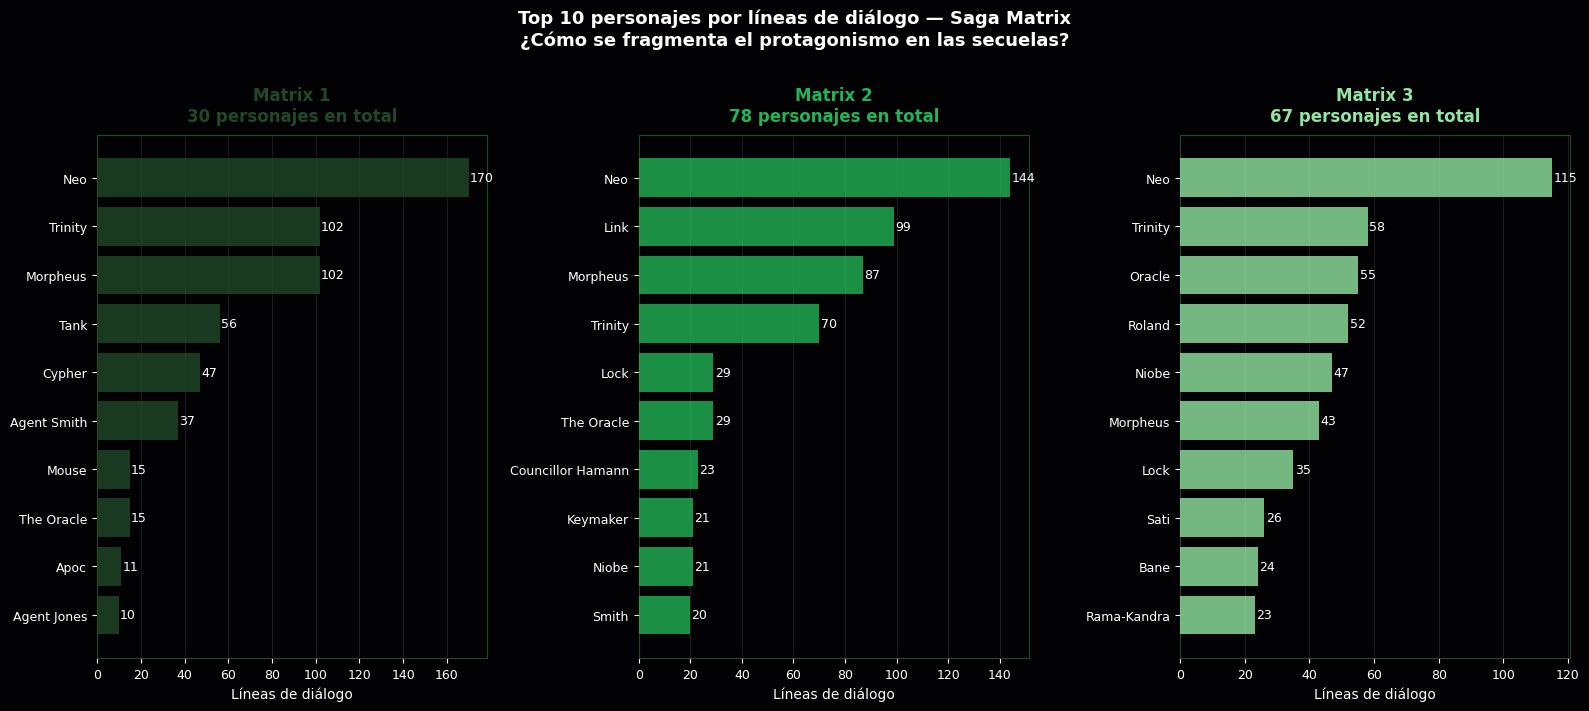

In [ ]:
# Función que devuelve los personajes con más líneas de diálogo

def top_personajes(df, n=10):
    
    return df.groupby('Character_Name').size().sort_values(ascending=True).tail(n)

top1 = top_personajes(m1)
top2 = top_personajes(m2)
top3 = top_personajes(m3)

# Tres gráficos horizontales, uno por película

fig, axes = plt.subplots(1, 3, figsize=(16, 7))
fig.patch.set_facecolor('#020204')

# Datos de cada gráfico: top personajes, título, color y total de personajes

datos = [
    (top1, 'Matrix 1', '#204829', f'{pers1} personajes en total'),
    (top2, 'Matrix 2', '#22b455', f'{pers2} personajes en total'),
    (top3, 'Matrix 3', '#92e5a1', f'{pers3} personajes en total'),
]

for ax, (top, titulo, color, subtitulo) in zip(axes, datos):
    ax.set_facecolor('#020204')
    bars = ax.barh(top.index, top.values, color=color, alpha=0.80, zorder=3)

    # Número de líneas al final de cada barra
    
    for bar, val in zip(bars, top.values):
        ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=9, color='white')

    ax.set_title(f'{titulo}\n{subtitulo}',
                 fontsize=12, fontweight='bold', color=color, pad=10)
    ax.set_xlabel('Líneas de diálogo', fontsize=10, color='white')
    ax.tick_params(colors='white', labelsize=9)
    ax.spines[:].set_color('#204829')
    ax.grid(True, axis='x', alpha=0.10, color='white')

fig.suptitle('Top 10 personajes por líneas de diálogo — Saga Matrix\n'
             '¿Cómo se fragmenta el protagonismo en las secuelas?',
             fontsize=13, fontweight='bold', color='white', y=1.01)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'personajes_dialogo.png'), dpi=150,
            bbox_inches='tight', facecolor='#020204')

#### Gráfico 2 — Complejidad del guion vs Valoración IMDb: Comparativa de las métricas clave junto con la valoración del público. Si la riqueza léxica es similar pero el número de personajes se dispara, el problema no fue la calidad de la escritura sino la estructura narrativa.

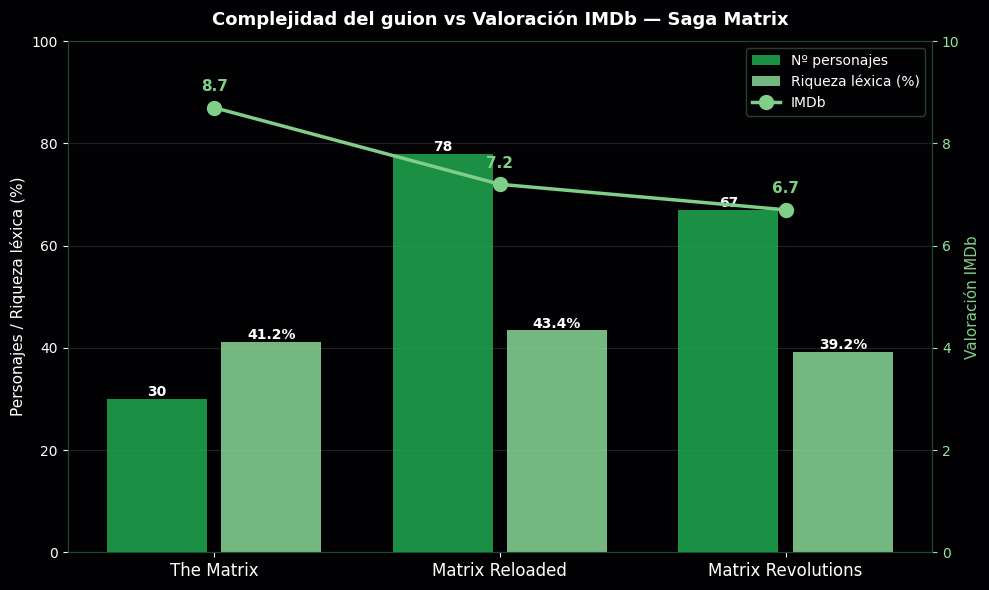

In [ ]:
# Datos de las tres películas: valoraciones IMDb y métricas calculadas anteriormente

peliculas = ['The Matrix', 'Matrix Reloaded', 'Matrix Revolutions']
imdb = [8.7, 7.2, 6.7]
personajes = [pers1, pers2, pers3]
riqueza = [riqueza1, riqueza2, riqueza3]

# Gráfico de barras dobles con eje secundario para la valoración IMDb

fig, ax1 = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#020204')
ax1.set_facecolor('#020204')

x = range(3)

# Barras de número de personajes y riqueza léxica, desplazadas para no solaparse

bars1 = ax1.bar([i - 0.2 for i in x], personajes, width=0.35,
                color='#22b455', alpha=0.80, label='Nº personajes', zorder=3)
bars2 = ax1.bar([i + 0.2 for i in x], riqueza, width=0.35,
                color='#92e5a1', alpha=0.80, label='Riqueza léxica (%)', zorder=3)

# Valor encima de cada barra

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{int(bar.get_height())}', ha='center', fontsize=10, color='white', fontweight='bold')
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', fontsize=10, color='white', fontweight='bold')

ax1.set_ylabel('Personajes / Riqueza léxica (%)', fontsize=11, color='white')
ax1.set_xticks(range(3))
ax1.set_xticklabels(peliculas, fontsize=12, color='white')
ax1.set_ylim(0, 100)
ax1.tick_params(colors='white')
ax1.spines[:].set_color('#204829')
ax1.grid(axis='y', alpha=0.12, color='white')

# Eje secundario para la valoración IMDb (escala 0-10) 

ax2 = ax1.twinx()
ax2.plot(range(3), imdb, color='#80ce87', linewidth=2.5,
         marker='o', markersize=10, label='IMDb', zorder=4)
ax2.set_ylabel('Valoración IMDb', fontsize=11, color='#80ce87')
ax2.set_ylim(0, 10)
ax2.tick_params(axis='y', colors='#92e5a1')
ax2.spines[:].set_color('#204829')

# Anotación del valor IMDb encima de cada punto

for i, v in enumerate(imdb):
    ax2.annotate(f'{v}', xy=(i, v), xytext=(0, 12),
                 textcoords='offset points', ha='center',
                 fontsize=11, color='#80ce87', fontweight='bold')

# Leyenda combinada de los dos ejes

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           fontsize=10, framealpha=0.3, facecolor='#020204',
           labelcolor='white', edgecolor='#80ce87', loc='upper right')

ax1.set_title('Complejidad del guion vs Valoración IMDb — Saga Matrix',
              fontsize=13, fontweight='bold', color='white', pad=12)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'complejidad_imdb.png'), dpi=150,
            bbox_inches='tight', facecolor='#020204')

#### Gráfico 3 — Longitud de las frases: ¿diálogos más cortos en las secuelas?: Si _The Matrix_ tenía grandes monólogos filosóficos y las secuelas se fragmentaron en diálogos de acción más cortos, debería verse en la distribución de palabras por frase. Analizamos las tres películas desde tres ángulos complementarios.

***

## 💊🔓 Conclusión final